In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import warnings
warnings.filterwarnings('ignore')
from dotenv import load_dotenv; load_dotenv('C:\git-repository\Blog\.gitignore\.env')
import requests
import fredapi as fa
import seaborn as sns
import statsmodels.api as sm
import xgboost as xgb
from pandas_datareader import data as pdr 
from sklearn.model_selection import (TimeSeriesSplit, RandomizedSearchCV, GridSearchCV, train_test_split)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import (LogisticRegressionCV, Ridge, RidgeCV, LassoCV)
from sklearn.metrics import (
    log_loss,
    balanced_accuracy_score,
    roc_auc_score,
    roc_curve,
    make_scorer,
    f1_score,
    confusion_matrix,
    classification_report,
    mean_squared_error,
    r2_score,
    mean_absolute_error,
    ConfusionMatrixDisplay
)

<>:7: SyntaxWarning: invalid escape sequence '\g'
<>:7: SyntaxWarning: invalid escape sequence '\g'
C:\Users\paulp\AppData\Local\Temp\ipykernel_57080\3275843338.py:7: SyntaxWarning: invalid escape sequence '\g'
  from dotenv import load_dotenv; load_dotenv('C:\git-repository\Blog\.gitignore\.env')


The U.S. Employment Situation Report is one of the most closely watched economic releases, often driving significant repricing across Treasury, equity, and foreign exchange markets. Because financial markets react to deviations from expectations rather than the headline payroll figure itself, this project focuses on forecasting labor market surprises rather than employment growth alone.

Using publicly available macroeconomic, labor market, and financial market data from the Bureau of Labor Statistics (BLS) and the Federal Reserve Economic Data (FRED) database, I construct a proxy consensus forecast for monthly nonfarm payroll growth and estimate labor report surprises as forecast residuals. These surprises are then modeled using machine learning techniques, including XGBoost, to identify the economic and market conditions most associated with upside and downside payroll surprises.

The objective is to develop a transparent, data-driven framework that replicates the expectation formation process used by market participants while demonstrating the application of econometrics, feature engineering, and machine learning to a real-world macroeconomic forecasting problem.

#### FRED Data Calls

In [3]:
series = [
    'PAYEMS',
    'UNRATE',
    'ICSA',
    'CCSA',
    'DGS2',
    'DGS10',
    'T10Y2Y',
    'UMCSENT'
    ]

start = '2000-01-01'
end = '2025-01-01'

df = pdr.DataReader(
    series,
    'fred',
    start,
    end
)

fred_df = df.resample('M').mean()
fred_df = fred_df.ffill()

In [4]:
fred_df = fred_df.rename(
    columns={
        'PAYEMS': 'payrolls', 
        'UNRATE': 'unemployment_rate', 
        'ICSA': 'initial_claims', 
        'CCSA': 'cont_claims', 
        'DGS2': '2yr_yield', 
        'DGS10': '10yr_yield',
        'T10Y2Y': '10yr_2yr_spread',
        'UMCSENT': 'sentiment'
        }).reset_index()

In [5]:
fred_df['month'] = fred_df['DATE'].dt.month
fred_df['year'] = fred_df['DATE'].dt.year

fred_df.head()

,DATE,payrolls,unemployment_rate,initial_claims,cont_claims,2yr_yield,10yr_yield,10yr_2yr_spread,sentiment,month,year
0,2000-01-31,131011.0,4.0,288400.0,2109800.0,6.440000,6.661000,0.221000,112.0,1,2000
1,2000-02-29,131120.0,4.1,293750.0,2147500.0,6.610500,6.519500,-0.091000,111.3,2,2000
2,2000-03-31,131604.0,4.0,274750.0,2079000.0,6.528261,6.256522,-0.271739,107.1,3,2000
3,2000-04-30,131884.0,3.8,271600.0,2015400.0,6.403684,5.990526,-0.413158,109.2,4,2000
4,2000-05-31,132105.0,4.0,282250.0,1989500.0,6.809545,6.440455,-0.369091,110.7,5,2000


#### BLS Data Calls

In [6]:
import json
import prettytable
bls_key = os.getenv('BLS')

In [7]:
BLS_ENDPOINT = "https://api.bls.gov/publicAPI/v2/timeseries/data/"

def fetch_bls_series(series, **kwargs):
    if len(series) < 1 or len(series) > 25:
        raise ValueError("Must pass in between 1 and 25 series ids")
    # Create headers and payload post data
    headers = {'Content-Type': 'application/json'}
    payload = {
        'seriesid': series,
        'registrationKey': bls_key,
    }
    # Update the payload with the keyword arguments and convert to JSON
    payload.update(kwargs)
    payload = json.dumps(payload)
    # Fetch the response from the BLS API
    response = requests.post(BLS_ENDPOINT, data=payload, headers=headers)
    response.raise_for_status()
    # Parse the JSON result
    #result = response.json()
    result = json.loads(response.text)
    if result['status'] != 'REQUEST_SUCCEEDED':
        raise Exception(result['message'][0])
    return result

In [8]:
series = ['JTS000000000000000JOR', 'JTS000000000000000HIR', 'JTS000000000000000QUR', 'JTS000000000000000LDR']
start_year = 1999
end_year = 2026
json_data = fetch_bls_series(series, startyear=start_year, endyear=end_year)

try:
    dfs = []

    for series in json_data['Results']['series']:
        df_initial = pd.DataFrame(series)
        series_col = df_initial['seriesID'][0]

        for i in range(0, len(df_initial) - 1):
            df_row = pd.DataFrame(df_initial['data'][i])
            df_row['seriesID'] = series_col

            if 'code' not in str(df_row['footnotes']): 
                df_row['footnotes'] = ''
            else:
                df_row['footnotes'] = str(df_row['footnotes']).split("'code': '", 1)[1][:1]

            dfs.append(df_row)

    df = pd.concat(dfs, ignore_index=True)

    df.to_csv('blsdata.csv', index=False)

except Exception as e:
    json_data['status'] == 'REQUEST_NOT_PROCESSED'
    print('BLS API has given the following Response:', json_data['status'])
    print('Reason:', json_data['message'])
    print('Error:', str(e))

In [9]:
openings_01_09_df = (
    df[df['seriesID'] == 'JTS000000000000000JOR']
    #.drop_duplicates('periodName')
    .set_index('periodName')[['value', 'year']]
    .rename(columns={'value':'job openings rate'})
)

hires_01_09_df = (
    df[df['seriesID'] == 'JTS000000000000000HIR']
    #.drop_duplicates('periodName')
    .set_index('periodName')[['value']]
    .rename(columns={'value':'hires rate'})
)

quit_01_09_df = (
    df[df['seriesID'] == 'JTS000000000000000QUR']
    #.drop_duplicates('periodName')
    .set_index('periodName')[['value']]
    .rename(columns={'value':'quit rate'})
)

discharge_01_09_df = (
    df[df['seriesID'] == 'JTS000000000000000LDR']
    #.drop_duplicates('periodName')
    .set_index('periodName')[['value']]
    .rename(columns={'value':'discharge rate'})
)

bls_01_09_df = (
    openings_01_09_df
    .join(hires_01_09_df, how='outer')
    .join(quit_01_09_df, how='outer')
    .join(discharge_01_09_df, how='outer')
)

print(bls_01_09_df['year'].unique())

['2018' '2017' '2016' '2015' '2014' '2013' '2012' '2011' '2010' '2009'
 '2008' '2007' '2006' '2005' '2004' '2003' '2002' '2001']


In [10]:
series = ['JTS000000000000000JOR', 'JTS000000000000000HIR', 'JTS000000000000000QUR', 'JTS000000000000000LDR']
start_year = 2019
end_year = 2026
json_data = fetch_bls_series(series, startyear=start_year, endyear=end_year)

try:
    dfs = []

    for series in json_data['Results']['series']:
        df_initial = pd.DataFrame(series)
        series_col = df_initial['seriesID'][0]

        for i in range(0, len(df_initial) - 1):
            df_row = pd.DataFrame(df_initial['data'][i])
            df_row['seriesID'] = series_col

            if 'code' not in str(df_row['footnotes']): 
                df_row['footnotes'] = ''
            else:
                df_row['footnotes'] = str(df_row['footnotes']).split("'code': '", 1)[1][:1]
    
            dfs.append(df_row)

    df = pd.concat(dfs, ignore_index=True)

    df.to_csv('blsdata.csv', index=False)

except Exception as e:
    json_data['status'] == 'REQUEST_NOT_PROCESSED'
    print('BLS API has given the following Response:', json_data['status'])
    print('Reason:', json_data['message'])
    print('Error:', str(e))

In [11]:
openings_19_26_df = (
    df[df['seriesID'] == 'JTS000000000000000JOR']
    #.drop_duplicates('periodName')
    .set_index('periodName')[['value', 'year']]
    .rename(columns={'value':'job openings rate'})
)

hires_19_26_df = (
    df[df['seriesID'] == 'JTS000000000000000HIR']
    #.drop_duplicates('periodName')
    .set_index('periodName')[['value']]
    .rename(columns={'value':'hires rate'})
)

quit_19_26_df = (
    df[df['seriesID'] == 'JTS000000000000000QUR']
    #.drop_duplicates('periodName')
    .set_index('periodName')[['value']]
    .rename(columns={'value':'quit rate'})
)

discharge_19_26_df = (
    df[df['seriesID'] == 'JTS000000000000000LDR']
    #.drop_duplicates('periodName')
    .set_index('periodName')[['value']]
    .rename(columns={'value':'discharge rate'})
)

bls_19_26_df = (
    openings_19_26_df
    .join(hires_19_26_df, how='outer')
    .join(quit_19_26_df, how='outer')
    .join(discharge_19_26_df, how='outer')
)
print(bls_19_26_df['year'].unique())

['2025' '2024' '2023' '2022' '2021' '2020' '2019' '2026']


In [12]:
bls_df = pd.concat([bls_01_09_df, bls_19_26_df]).reset_index()

print(bls_df.dtypes)
bls_df.head()

periodName           object
job openings rate    object
year                 object
hires rate           object
quit rate            object
discharge rate       object
dtype: object


,periodName,job openings rate,year,hires rate,quit rate,discharge rate
0,April,4.4,2018,3.8,2.3,1.2
1,April,4.4,2018,3.8,2.3,1.2
2,April,4.4,2018,3.8,2.3,1.2
3,April,4.4,2018,3.8,2.3,1.3
4,April,4.4,2018,3.8,2.3,1.3


In [13]:
bls_df['month_year'] = bls_df['periodName'] + ' ' + bls_df['year'].astype(str)

num_cols = [
    'job openings rate',
    'hires rate',
    'quit rate',
    'discharge rate'
    ]
bls_df[num_cols] = bls_df[num_cols].apply(
    pd.to_numeric,
    errors='coerce'
)

In [14]:
bls_df = bls_df.groupby(
    'month_year'
    ).agg(
        job_opening_rate = ('job openings rate', 'mean'),
        hire_rate = ('hires rate', 'mean'),
        quit_rate = ('quit rate', 'mean'),
        discharge_rate = ('discharge rate', 'mean')
    ).reset_index()
print(bls_df.dtypes)

month_year           object
job_opening_rate    float64
hire_rate           float64
quit_rate           float64
discharge_rate      float64
dtype: object


In [15]:
bls_df['month_year'] = pd.to_datetime(bls_df['month_year'])

bls_df['month'] = bls_df['month_year'].dt.month
bls_df['year'] = bls_df['month_year'].dt.year

In [16]:
bls_df['month']
bls_df = bls_df.sort_values('month_year')#.reset_index()

In [17]:
bls_df.head()

,month_year,job_opening_rate,hire_rate,quit_rate,discharge_rate,month,year
101,2001-01-01,3.8,3.605556,1.894444,1.422222,1,2001
75,2001-02-01,3.7,3.600000,1.905556,1.388889,2,2001
176,2001-03-01,3.5,3.633333,1.894444,1.422222,3,2001
0,2001-04-01,3.4,3.600000,1.894444,1.405556,4,2001
202,2001-05-01,3.2,3.616667,1.877778,1.400000,5,2001


#### Combining FRED and BLS Datasets

In [18]:
master_df = pd.merge(
    fred_df,
    bls_df,
    on=['year', 'month'],
    how='inner'
)

master_df.head()    

,DATE,payrolls,unemployment_rate,initial_claims,cont_claims,2yr_yield,10yr_yield,10yr_2yr_spread,sentiment,month,year,month_year,job_opening_rate,hire_rate,quit_rate,discharge_rate
0,2001-01-31,132703.0,4.2,340000.0,2395750.0,4.760000,5.160952,0.400952,94.7,1,2001,2001-01-01,3.8,3.605556,1.894444,1.422222
1,2001-02-28,132788.0,4.2,371250.0,2486500.0,4.656842,5.098947,0.442105,90.6,2,2001,2001-02-01,3.7,3.600000,1.905556,1.388889
2,2001-03-31,132751.0,4.3,387200.0,2585400.0,4.342273,4.885455,0.543182,91.5,3,2001,2001-03-01,3.5,3.633333,1.894444,1.422222
3,2001-04-30,132458.0,4.4,396750.0,2697250.0,4.234000,5.141000,0.907000,88.4,4,2001,2001-04-01,3.4,3.600000,1.894444,1.405556
4,2001-05-31,132408.0,4.3,394500.0,2819250.0,4.260000,5.391364,1.131364,92.0,5,2001,2001-05-01,3.2,3.616667,1.877778,1.400000


#### Feature Engineering

In [19]:
# FRED features

master_df['sentiment_lag1'] = master_df['sentiment'].shift(1)
master_df['payrolls_lag1'] = master_df['payrolls'].shift(1)
master_df['payrolls_change'] = master_df['payrolls'].diff()
master_df['unemployment_rate_3mo_avg'] = master_df['unemployment_rate'].rolling(3).mean()
master_df['initial_claims_lag1'] = master_df['initial_claims'].shift(1)
master_df['initial_claims_momentum'] = master_df['initial_claims'].diff(3)
master_df['cont_claims_lag1'] = master_df['cont_claims'].shift(1)
master_df['cont_claims_momentum'] = master_df['cont_claims'].diff(3)
master_df['2yr_yield_volatility'] = master_df['2yr_yield'].rolling(3).std()
master_df['10yr_yield_volatility'] = master_df['10yr_yield'].rolling(3).std()

In [20]:
# BLS Features

master_df['jor_3mo_avg'] = master_df['job_opening_rate'].rolling(3).mean()
master_df['jor_momentum'] = master_df['job_opening_rate'].diff(3)
master_df['hire_3mo_avg'] = master_df['hire_rate'].rolling(3).mean()
master_df['hire_momentum'] = master_df['hire_rate'].diff(3)
master_df['quit_3mo_avg'] = master_df['quit_rate'].rolling(3).mean()
master_df['quit_momentum'] = master_df['quit_rate'].diff(3)
master_df['discharge_3mo_avg'] = master_df['discharge_rate'].rolling(3).mean()
master_df['discharge_momentum'] = master_df['discharge_rate'].diff(3)

In [21]:
master_df = master_df.dropna().reset_index(drop=True)
print(master_df.columns)

Index(['DATE', 'payrolls', 'unemployment_rate', 'initial_claims',
       'cont_claims', '2yr_yield', '10yr_yield', '10yr_2yr_spread',
       'sentiment', 'month', 'year', 'month_year', 'job_opening_rate',
       'hire_rate', 'quit_rate', 'discharge_rate', 'sentiment_lag1',
       'payrolls_lag1', 'payrolls_change', 'unemployment_rate_3mo_avg',
       'initial_claims_lag1', 'initial_claims_momentum', 'cont_claims_lag1',
       'cont_claims_momentum', '2yr_yield_volatility', '10yr_yield_volatility',
       'jor_3mo_avg', 'jor_momentum', 'hire_3mo_avg', 'hire_momentum',
       'quit_3mo_avg', 'quit_momentum', 'discharge_3mo_avg',
       'discharge_momentum'],
      dtype='object')


#### Constructing a Proxy for Consensus Forecasts

Financial markets react not to the headline nonfarm payroll figure itself, but to the difference between the reported value and market expectations. Professional investors typically rely on consensus forecasts compiled from surveys of economists and market participants. However, high-quality consensus forecast data is generally proprietary and not freely available.

To address this limitation, I opted to construct a proxy expectations model using publically available macroeconomic data. A Ridge Regression model was chosen to generate monthly payroll forecasts because it provides a transparent and interpretable framework while mitigating overfitting and multicollinearity. 

The resulting forecast serves as a proxy for market expectations. Labor report surprises are then calculated as the difference between the actual change in payrolls and the expected change in payrolls as generated by the model. 

In [22]:
features_l2 = [
    'unemployment_rate_3mo_avg',
    'initial_claims_lag1',
    'initial_claims_momentum',
    'cont_claims_lag1',
    'cont_claims_momentum',
    '2yr_yield_volatility',
    '10yr_yield_volatility',
    'jor_3mo_avg',
    'jor_momentum',
    'hire_3mo_avg',
    'hire_momentum',
    'quit_3mo_avg',
    'quit_momentum',
    'discharge_3mo_avg',
    'discharge_momentum'
]

X_l2 = master_df[features_l2]
y_l2 = master_df['payrolls_change'] # MODELING CHANGE IN PAYROLLS RATHER THAN LEVELS TO AVOID NON-STATIONARITY ISSUES

split = int(len(master_df) * 0.8)
X_l2_train = X_l2.iloc[:split]
X_l2_test = X_l2.iloc[split:]
y_l2_train = y_l2.iloc[:split]
y_l2_test = y_l2.iloc[split:]

In [23]:
model_expectation = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', RidgeCV(alphas=np.logspace(-3, 3, 25), cv=TimeSeriesSplit(n_splits=5)))
])

In [24]:
model_expectation.fit(X_l2_train, y_l2_train)

y_l2_pred = model_expectation.predict(X_l2_test)

mae = mean_absolute_error(y_l2_test, y_l2_pred)
mse = mean_squared_error(y_l2_test, y_l2_pred)
r2 = r2_score(y_l2_test, y_l2_pred)

print(f"MAE: {mae}")
print(f"MSE: {mse}")
print(f"R^2: {r2}")

MAE: 1985.0788007683445
MSE: 25694205.7669258
R^2: -49.45097551364819


In [25]:
master_df['payrolls_change_pred'] = model_expectation.predict(X_l2)
master_df['payrolls_change_diff'] = master_df['payrolls_change_pred'] - master_df['payrolls_change']
master_df['upward_surprise'] = master_df['payrolls_change_diff'].apply(lambda x: 1 if x > 0 else 0)
master_df['downward_surprise'] = master_df['payrolls_change_diff'].apply(lambda x: 1 if x < 0 else 0)

print(master_df.value_counts('upward_surprise'))
master_df.head()

upward_surprise
0    158
1    127
Name: count, dtype: int64


,DATE,payrolls,unemployment_rate,initial_claims,cont_claims,2yr_yield,10yr_yield,10yr_2yr_spread,sentiment,month,...,hire_3mo_avg,hire_momentum,quit_3mo_avg,quit_momentum,discharge_3mo_avg,discharge_momentum,payrolls_change_pred,payrolls_change_diff,upward_surprise,downward_surprise
0,2001-04-30,132458.0,4.4,396750.0,2697250.0,4.234000,5.141000,0.907000,88.4,4,...,3.611111,-0.005556,1.898148,0.000000,1.405556,-0.016667,-594.417801,-301.417801,0,1
1,2001-05-31,132408.0,4.3,394500.0,2819250.0,4.260000,5.391364,1.131364,92.0,5,...,3.616667,0.016667,1.888889,-0.027778,1.409259,0.011111,-469.363130,-419.363130,0,1
2,2001-06-30,132300.0,4.5,397200.0,2947400.0,4.080000,5.284286,1.204286,92.6,6,...,3.603704,-0.038889,1.887037,-0.005556,1.407407,-0.005556,-426.722979,-318.722979,0,1
3,2001-07-31,132172.0,4.6,398000.0,3030750.0,4.038571,5.236190,1.197619,92.4,7,...,3.603704,0.000000,1.879630,-0.022222,1.409259,0.005556,-367.608643,-239.608643,0,1
4,2001-08-31,132021.0,4.9,398000.0,3120000.0,3.757391,4.971304,1.213913,91.5,8,...,3.600000,-0.011111,1.881481,0.005556,1.411111,0.005556,-335.318851,-184.318851,0,1


#### Modeling Upside and Downside Surprises 

Rather than training a single multiclass model, I chose to build two separate XGBoost classifiers: one to predict *upside* payroll surprises and another to predict *downside* surprises. 

By training separate models, each classifier can focus on identifying the specific patterns and nonlinear relationships that precede its target outcome. For example, rising job openings and declining unemployment claims may be strong indicators of an upside surprise, while increasing layoffs and weakening labor demand may be more relevant for predicting downside surprises. Separating these prediction tasks allows the models to learn distinct signal structures and provides a more interpretable assessment of the factors associated with positive and negative labor market surprises.

In [26]:
features = [
    'sentiment_lag1',
    'payrolls_lag1',
    'payrolls_change',
    'unemployment_rate_3mo_avg',
    'initial_claims_lag1',
    'initial_claims_momentum',
    'cont_claims_lag1',
    'cont_claims_momentum',
    '2yr_yield_volatility',
    '10yr_yield_volatility',
    'jor_3mo_avg',
    'jor_momentum',
    'hire_3mo_avg',
    'hire_momentum',
    'quit_3mo_avg',
    'quit_momentum',
    'discharge_3mo_avg',
    'discharge_momentum'
]

Upside Surprise Model

In [27]:
# Upside Surprise Sets

X_upside = master_df[features]
y_upside = master_df['upward_surprise']

X_train_upside, X_test_upside, y_train_upside, y_test_upside = train_test_split(X_upside, y_upside, random_state=42)

In [28]:
# Initial XGBoost Model for Predicting Upside Surprises

upside_xgb = xgb.XGBClassifier(objective='binary:logistic',
                               eval_metric='auc',
                               seed=42)
upside_xgb.fit(X_train_upside, 
               y_train_upside,
               verbose=True,
               eval_set=[(X_test_upside, y_test_upside)]
               )

[0]	validation_0-auc:0.79391
[1]	validation_0-auc:0.83400
[2]	validation_0-auc:0.82478
[3]	validation_0-auc:0.84884


[4]	validation_0-auc:0.84763
[5]	validation_0-auc:0.85405
[6]	validation_0-auc:0.85124
[7]	validation_0-auc:0.84282
[8]	validation_0-auc:0.83921
[9]	validation_0-auc:0.85204
[10]	validation_0-auc:0.84723
[11]	validation_0-auc:0.85565
[12]	validation_0-auc:0.85966
[13]	validation_0-auc:0.85886
[14]	validation_0-auc:0.85405
[15]	validation_0-auc:0.85164
[16]	validation_0-auc:0.85084
[17]	validation_0-auc:0.85084
[18]	validation_0-auc:0.85164
[19]	validation_0-auc:0.85245
[20]	validation_0-auc:0.85084
[21]	validation_0-auc:0.85164
[22]	validation_0-auc:0.85004
[23]	validation_0-auc:0.85245
[24]	validation_0-auc:0.84924
[25]	validation_0-auc:0.85084
[26]	validation_0-auc:0.85004
[27]	validation_0-auc:0.85164
[28]	validation_0-auc:0.85325
[29]	validation_0-auc:0.85084
[30]	validation_0-auc:0.85325
[31]	validation_0-auc:0.85245
[32]	validation_0-auc:0.85405
[33]	validation_0-auc:0.85325
[34]	validation_0-auc:0.85405
[35]	validation_0-auc:0.85325
[36]	validation_0-auc:0.85164
[37]	validation_

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'auc'


The XGBoost classifier achieved a ROC-AUC score of 0.86 and an out-of-sample accuracy of 75% when identifying upside payroll surprises. The model correctly identified 22 of 29 upside surprise observations while maintaining a precision of 67% and recall of 76% for the upside surprise class. The resulting F1 score of 0.71 indicates a strong balance between identifying upside surprise events and limiting false positive signals. The confusion matrix shows that the model correctly classified 54 of 72 observations, including a substantial majority of upside surprise events. 

A key limitation of this analysis is that the surprise variable is defined relative to a model-generated proxy expectation rather than a true market consensus forecast. As a result, the model is effectively predicting deviations from the Ridge Regression forecast rather than deviations from economist expectations or market pricing. While this approach provides a reasonable approximation in the absence of freely available consensus data, the results should be interpreted as evidence of predictive power relative to the proxy expectations model rather than definitive forecasts of actual market surprises.

ROC AUC Score for Upside Surprise Model: 0.8613
Classification Report for Upside Surprises:
                     precision    recall  f1-score   support

No Upside Surprise       0.82      0.74      0.78        43
   Upside Surprise       0.67      0.76      0.71        29

          accuracy                           0.75        72
         macro avg       0.74      0.75      0.75        72
      weighted avg       0.76      0.75      0.75        72



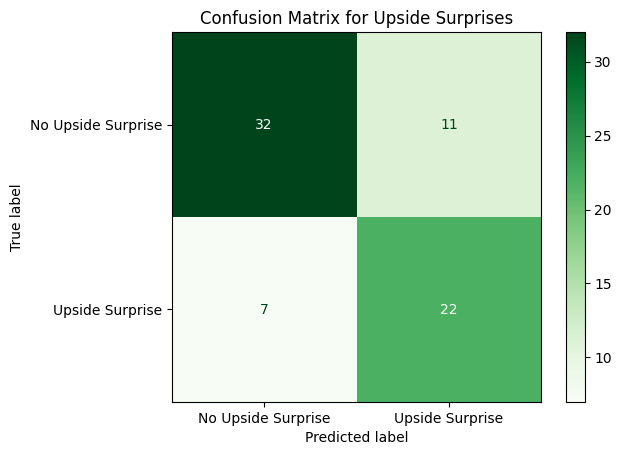

In [29]:
upside_xgb_report = classification_report(y_test_upside, upside_xgb.predict(X_test_upside), target_names=['No Upside Surprise', 'Upside Surprise'])
upside_y_probs = upside_xgb.predict_proba(X_test_upside)[:, 1]

print(f"ROC AUC Score for Upside Surprise Model: {roc_auc_score(y_test_upside, upside_y_probs):.4f}")
print("Classification Report for Upside Surprises:\n", upside_xgb_report)

ConfusionMatrixDisplay.from_estimator(upside_xgb, X_test_upside, y_test_upside, display_labels=['No Upside Surprise', 'Upside Surprise'], cmap='Greens')
plt.title('Confusion Matrix for Upside Surprises')
plt.show()

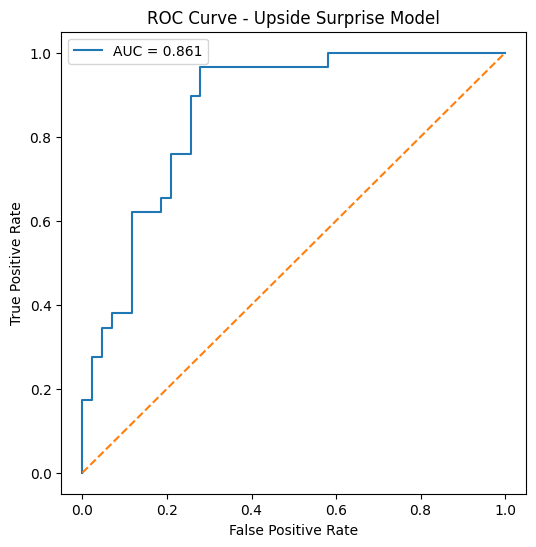

In [30]:
fpr, tpr, thresholds = roc_curve(
    y_test_upside,
    upside_y_probs
)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test_upside, upside_y_probs):.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Upside Surprise Model")
plt.legend()
plt.show()

The XGBoost classifier achieved 75% out-of-sample accuracy in identifying upside payroll surprises. The model correctly identified 22 of 29 upside surprise observations while maintaining a precision of 67% and recall of 76%. Results suggest that labor market and financial market indicators contain meaningful predictive information regarding the direction of payroll report surprises, though the model exhibits a tendency to generate some false positive signals.

In [31]:
# 1ST ROUND OF GRIDSEARCHCV

param_grid = {
    'max_depth': [1, 2, 3, 4, 5],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'n_estimators': [50, 100, 200, 300],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

params = RandomizedSearchCV(
    estimator=upside_xgb,
    param_distributions=param_grid,
    n_iter=50,
    scoring='roc_auc',
    cv=TimeSeriesSplit(n_splits=5),
    random_state=42
)

params.fit(X_train_upside, y_train_upside)
print(params.best_params_)
print(params.best_score_)

{'subsample': 1.0, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 1.0}
0.8250980727891484


In [32]:
# Optimized XGBoost Model for Predicting Upside Surprises

opt_upside_xgb = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='auc',
    **params.best_params_,
    seed=42
)
opt_upside_xgb.fit(X_train_upside, y_train_upside, 
                   verbose=True, 
                   eval_set=[(X_test_upside, y_test_upside)]
                   )

[0]	validation_0-auc:0.82277
[1]	validation_0-auc:0.79230
[2]	validation_0-auc:0.79992
[3]	validation_0-auc:0.80834
[4]	validation_0-auc:0.84122
[5]	validation_0-auc:0.84804
[6]	validation_0-auc:0.84603
[7]	validation_0-auc:0.84643
[8]	validation_0-auc:0.84804
[9]	validation_0-auc:0.85646
[10]	validation_0-auc:0.85164
[11]	validation_0-auc:0.85565
[12]	validation_0-auc:0.85766
[13]	validation_0-auc:0.85846
[14]	validation_0-auc:0.85966
[15]	validation_0-auc:0.85245
[16]	validation_0-auc:0.85565
[17]	validation_0-auc:0.85245
[18]	validation_0-auc:0.85565
[19]	validation_0-auc:0.85806
[20]	validation_0-auc:0.85686
[21]	validation_0-auc:0.85605
[22]	validation_0-auc:0.85485
[23]	validation_0-auc:0.85084
[24]	validation_0-auc:0.85325
[25]	validation_0-auc:0.85164
[26]	validation_0-auc:0.85084
[27]	validation_0-auc:0.85325
[28]	validation_0-auc:0.85565
[29]	validation_0-auc:0.85806
[30]	validation_0-auc:0.85966
[31]	validation_0-auc:0.86127
[32]	validation_0-auc:0.85806
[33]	validation_0-au

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,1.0
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'auc'


Optimized Upside Surprise Model

ROC AUC Score for Optimized Upside Surprise Model: 0.8589
Classification Report for Optimized Upside Surprises:
                     precision    recall  f1-score   support

No Upside Surprise       0.85      0.79      0.82        43
   Upside Surprise       0.72      0.79      0.75        29

          accuracy                           0.79        72
         macro avg       0.78      0.79      0.79        72
      weighted avg       0.80      0.79      0.79        72



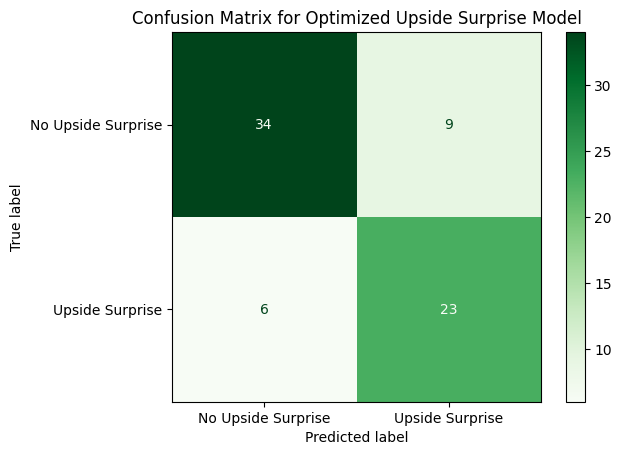

In [33]:
opt_upside_xgb_report = classification_report(y_test_upside, opt_upside_xgb.predict(X_test_upside), target_names=['No Upside Surprise', 'Upside Surprise'])
opt_upside_y_probs = opt_upside_xgb.predict_proba(X_test_upside)[:, 1]

print(f"ROC AUC Score for Optimized Upside Surprise Model: {roc_auc_score(y_test_upside, opt_upside_y_probs):.4f}")
print("Classification Report for Optimized Upside Surprises:\n", opt_upside_xgb_report)

ConfusionMatrixDisplay.from_estimator(opt_upside_xgb, X_test_upside, y_test_upside, display_labels=['No Upside Surprise', 'Upside Surprise'], cmap='Greens')
plt.title('Confusion Matrix for Optimized Upside Surprise Model')
plt.show()

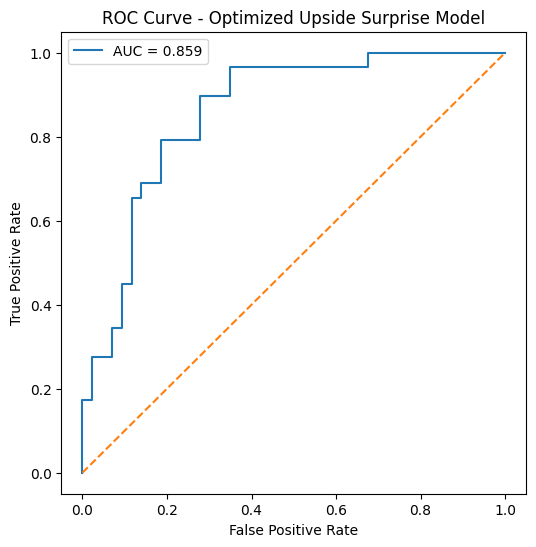

In [34]:
fpr, tpr, thresholds = roc_curve(
    y_test_upside,
    opt_upside_y_probs
)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test_upside, opt_upside_y_probs):.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Optimized Upside Surprise Model")
plt.legend()
plt.show()

Downside Surprise Model

In [35]:
X_downside = master_df[features]
y_downside = master_df['downward_surprise']

X_train_downside, X_test_downside, y_train_downside, y_test_downside = train_test_split(X_downside, y_downside, random_state=42)

In [36]:
downside_xgb = xgb.XGBClassifier(objective='binary:logistic',
                                 eval_metric='auc',
                                 seed=42)
downside_xgb.fit(X_train_downside, 
                y_train_downside,
                verbose=True,
                eval_set=[(X_test_downside, y_test_downside)]
                )

[0]	validation_0-auc:0.79391
[1]	validation_0-auc:0.83400
[2]	validation_0-auc:0.82478
[3]	validation_0-auc:0.84884
[4]	validation_0-auc:0.84763
[5]	validation_0-auc:0.85405
[6]	validation_0-auc:0.85124
[7]	validation_0-auc:0.84282
[8]	validation_0-auc:0.83921
[9]	validation_0-auc:0.85204
[10]	validation_0-auc:0.84723
[11]	validation_0-auc:0.85565
[12]	validation_0-auc:0.85966
[13]	validation_0-auc:0.85886
[14]	validation_0-auc:0.85405
[15]	validation_0-auc:0.85164
[16]	validation_0-auc:0.85084
[17]	validation_0-auc:0.85084
[18]	validation_0-auc:0.85164
[19]	validation_0-auc:0.85245
[20]	validation_0-auc:0.85084
[21]	validation_0-auc:0.85164
[22]	validation_0-auc:0.85004
[23]	validation_0-auc:0.85245
[24]	validation_0-auc:0.84924
[25]	validation_0-auc:0.85084
[26]	validation_0-auc:0.85004
[27]	validation_0-auc:0.85164
[28]	validation_0-auc:0.85325
[29]	validation_0-auc:0.85084
[30]	validation_0-auc:0.85325
[31]	validation_0-auc:0.85245
[32]	validation_0-auc:0.85405
[33]	validation_0-au

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'auc'


ROC AUC Score for Optimized Downside Surprise Model: 0.8613
Classification Report for Optimized Downside Surprises:
                       precision    recall  f1-score   support

No Downside Surprise       0.67      0.76      0.71        29
   Downside Surprise       0.82      0.74      0.78        43

            accuracy                           0.75        72
           macro avg       0.74      0.75      0.75        72
        weighted avg       0.76      0.75      0.75        72



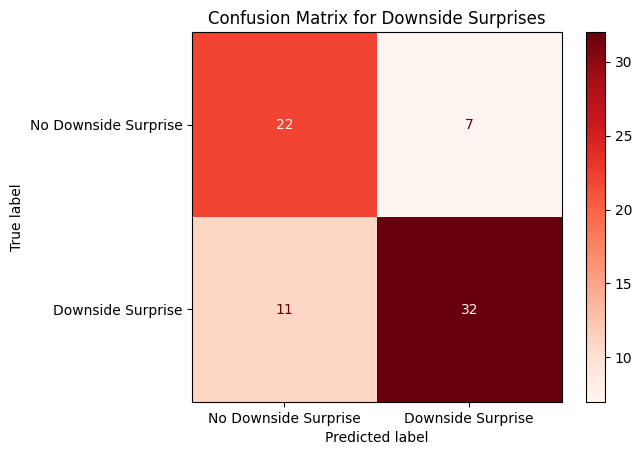

In [37]:
downside_xgb_report = classification_report(y_test_downside, downside_xgb.predict(X_test_downside), target_names=['No Downside Surprise', 'Downside Surprise'])
downside_y_probs = downside_xgb.predict_proba(X_test_downside)[:, 1]

print(f"ROC AUC Score for Optimized Downside Surprise Model: {roc_auc_score(y_test_downside, downside_y_probs):.4f}")
print("Classification Report for Optimized Downside Surprises:\n", downside_xgb_report)

ConfusionMatrixDisplay.from_estimator(downside_xgb, X_test_downside, y_test_downside, display_labels=['No Downside Surprise', 'Downside Surprise'], cmap='Reds')
plt.title('Confusion Matrix for Downside Surprises')
plt.show()

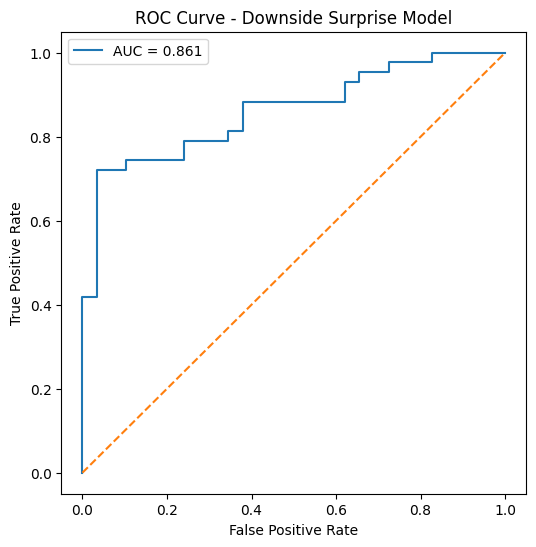

In [42]:
fpr, tpr, thresholds = roc_curve(
    y_test_downside,
    downside_y_probs
)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test_downside, downside_y_probs):.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Downside Surprise Model")
plt.legend()
plt.show()

Optimized Downside Model

In [39]:
params = RandomizedSearchCV(
    estimator=downside_xgb,
    param_distributions=param_grid,
    n_iter=50,
    scoring='roc_auc',
    cv=TimeSeriesSplit(n_splits=5),
    random_state=42
)

params.fit(X_train_downside, y_train_downside)
print(params.best_params_)
print(params.best_score_)

{'subsample': 1.0, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 1.0}
0.8250980727891483


In [40]:
opt_downside_xgb = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='auc',
    **params.best_params_,
    seed=42
)
opt_downside_xgb.fit(X_train_downside, y_train_downside, verbose=True, eval_set=[(X_test_downside, y_test_downside)])

[0]	validation_0-auc:0.82277
[1]	validation_0-auc:0.79230
[2]	validation_0-auc:0.79992
[3]	validation_0-auc:0.80834
[4]	validation_0-auc:0.84122
[5]	validation_0-auc:0.84804
[6]	validation_0-auc:0.84603
[7]	validation_0-auc:0.84643
[8]	validation_0-auc:0.84804
[9]	validation_0-auc:0.85646
[10]	validation_0-auc:0.85164
[11]	validation_0-auc:0.85565
[12]	validation_0-auc:0.85766
[13]	validation_0-auc:0.85846
[14]	validation_0-auc:0.85966
[15]	validation_0-auc:0.85245
[16]	validation_0-auc:0.85565
[17]	validation_0-auc:0.85245
[18]	validation_0-auc:0.85565
[19]	validation_0-auc:0.85806
[20]	validation_0-auc:0.85686
[21]	validation_0-auc:0.85605
[22]	validation_0-auc:0.85485
[23]	validation_0-auc:0.85084
[24]	validation_0-auc:0.85325
[25]	validation_0-auc:0.85164
[26]	validation_0-auc:0.85084
[27]	validation_0-auc:0.85325
[28]	validation_0-auc:0.85565
[29]	validation_0-auc:0.85806
[30]	validation_0-auc:0.85966
[31]	validation_0-auc:0.86127
[32]	validation_0-auc:0.85806
[33]	validation_0-au

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,1.0
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'auc'


ROC AUC Score for Optimized Downside Surprise Model: 0.8589
Classification Report for Optimized Downside Surprises:
                       precision    recall  f1-score   support

No Downside Surprise       0.72      0.79      0.75        29
   Downside Surprise       0.85      0.79      0.82        43

            accuracy                           0.79        72
           macro avg       0.78      0.79      0.79        72
        weighted avg       0.80      0.79      0.79        72



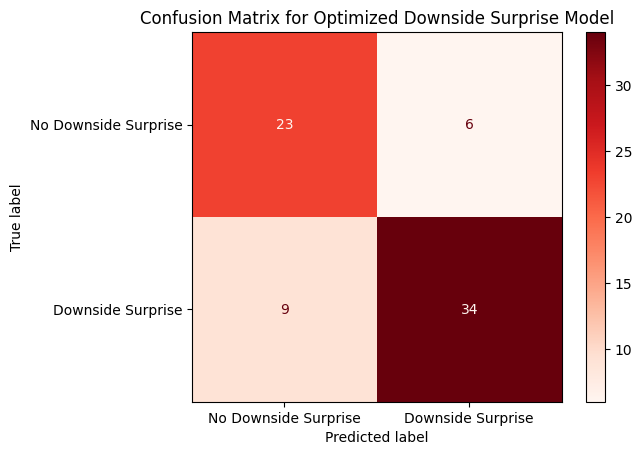

In [41]:
opt_downside_xgb_report = classification_report(y_test_downside, opt_downside_xgb.predict(X_test_downside), target_names=['No Downside Surprise', 'Downside Surprise'])
opt_downside_y_probs = opt_downside_xgb.predict_proba(X_test_downside)[:, 1]

print(f"ROC AUC Score for Optimized Downside Surprise Model: {roc_auc_score(y_test_downside, opt_downside_y_probs):.4f}")
print("Classification Report for Optimized Downside Surprises:\n", opt_downside_xgb_report)

ConfusionMatrixDisplay.from_estimator(opt_downside_xgb, X_test_downside, y_test_downside, display_labels=['No Downside Surprise', 'Downside Surprise'], cmap='Reds')
plt.title('Confusion Matrix for Optimized Downside Surprise Model')
plt.show()

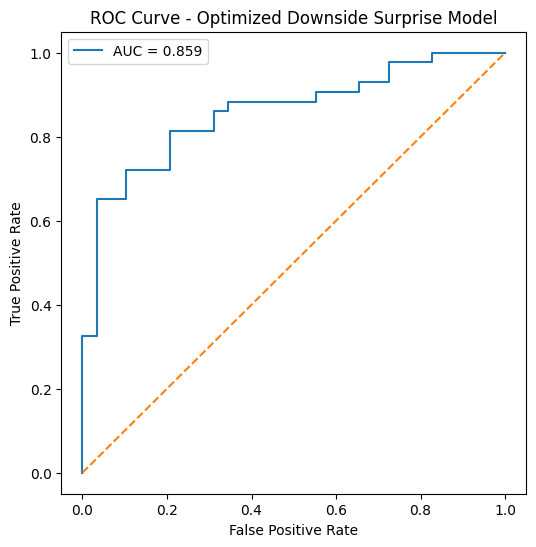

In [43]:
fpr, tpr, thresholds = roc_curve(
    y_test_downside,
    opt_downside_y_probs
)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test_downside, opt_downside_y_probs):.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Optimized Downside Surprise Model")
plt.legend()
plt.show()